In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline


In [2]:
train=pd.read_csv("files/titanic_train.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<h1>Exploratory Data Analysis </h1>

using seaborn create heatmap to visualize missing values

<Axes: >

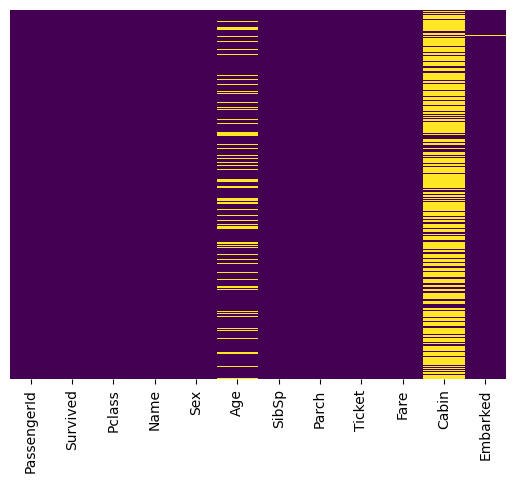

In [4]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis') 
# yticklabel is show row no not neede when large dataset so false
#cbar tells the color mean , cbar= color bar
# cmap is to give color virdis is best for missing values


<Axes: >

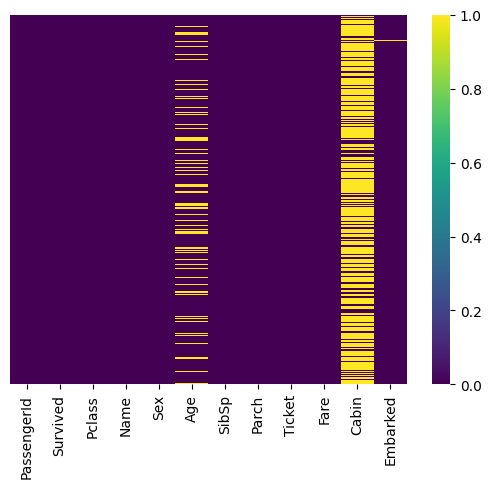

In [5]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=True,cmap='viridis')

Sure! Here's the explanation and list of color map options written in **Markdown**:

---

## 🎨 Choosing a Color Map in Seaborn Heatmaps

When using `sns.heatmap()`, the `cmap` parameter controls the color scheme of the heatmap. You can use different colormaps depending on your goal (e.g., showing intensity, highlighting differences, or categorical separation).

---

### ✅ Syntax Example

```python
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='magma')
```

Replace `'magma'` with any of the color maps below.

---

## 🔵 Sequential Colormaps

Good for showing a progression in intensity (e.g., from low to high values):

| Colormap    | Description                        |
| ----------- | ---------------------------------- |
| `'magma'`   | Dark purple → orange/yellow        |
| `'plasma'`  | Purple → yellow                    |
| `'inferno'` | Black → orange/yellow              |
| `'cividis'` | Colorblind-friendly, blue → yellow |
| `'Blues'`   | Light blue → dark blue             |
| `'Greens'`  | Light green → dark green           |
| `'Oranges'` | Light orange → dark orange         |

---

## 🔁 Diverging Colormaps

Best when you want to show deviation from a central value (e.g., 0):

| Colormap     | Description          |
| ------------ | -------------------- |
| `'coolwarm'` | Blue → white → red   |
| `'RdBu'`     | Red → white → blue   |
| `'PiYG'`     | Pink → white → green |

---

## 🟥 Categorical Colormaps

Use these when plotting discrete or labeled data:

| Colormap    | Description                     |
| ----------- | ------------------------------- |
| `'Set1'`    | Bright, distinguishable colors  |
| `'Pastel1'` | Softer, pastel colors           |
| `'tab10'`   | 10 distinct, color-safe options |

---

## ℹ️ Notes

* For **missing value heatmaps** (`train.isnull()`), high-contrast sequential colormaps like `'magma'`, `'cividis'`, or `'Blues'` work well.
* To view all available colormaps:

  ```python
  import matplotlib.pyplot as plt
  plt.colormaps()
  ```

Would you like a visualization comparing a few colormaps?


<Axes: xlabel='Survived', ylabel='count'>

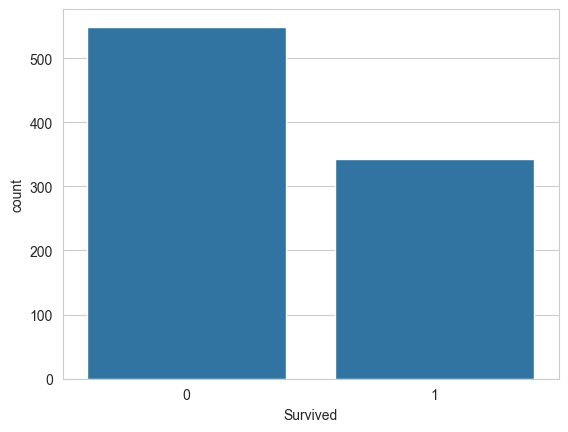

In [13]:
sns.set_style('whitegrid') #create a lining in bg 
sns.countplot(x="Survived",data=train)

<Axes: xlabel='Survived', ylabel='count'>

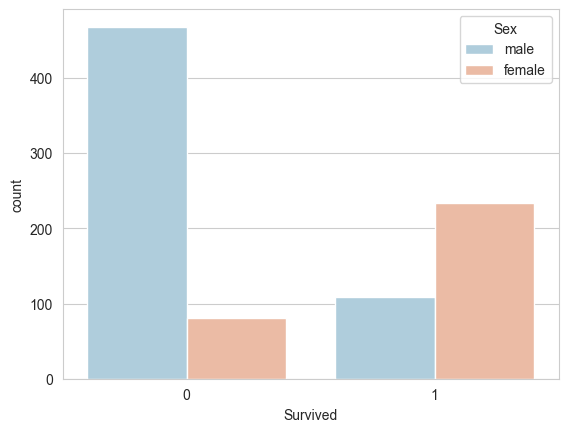

In [15]:
sns.set_style('whitegrid')
sns.countplot(x="Survived",hue="Sex",data=train,palette="RdBu_r")

<Axes: xlabel='Survived', ylabel='count'>

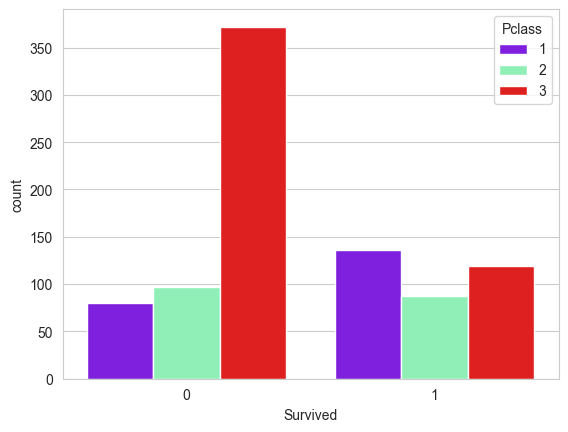

In [18]:
sns.set_style('whitegrid')
sns.countplot(x="Survived",data=train,hue='Pclass',palette="rainbow")

now we will check about avg value of each class age and replace it in nan

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13136\3480124998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass",y="Age",palette="winter",data=train)


<Axes: xlabel='Pclass', ylabel='Age'>

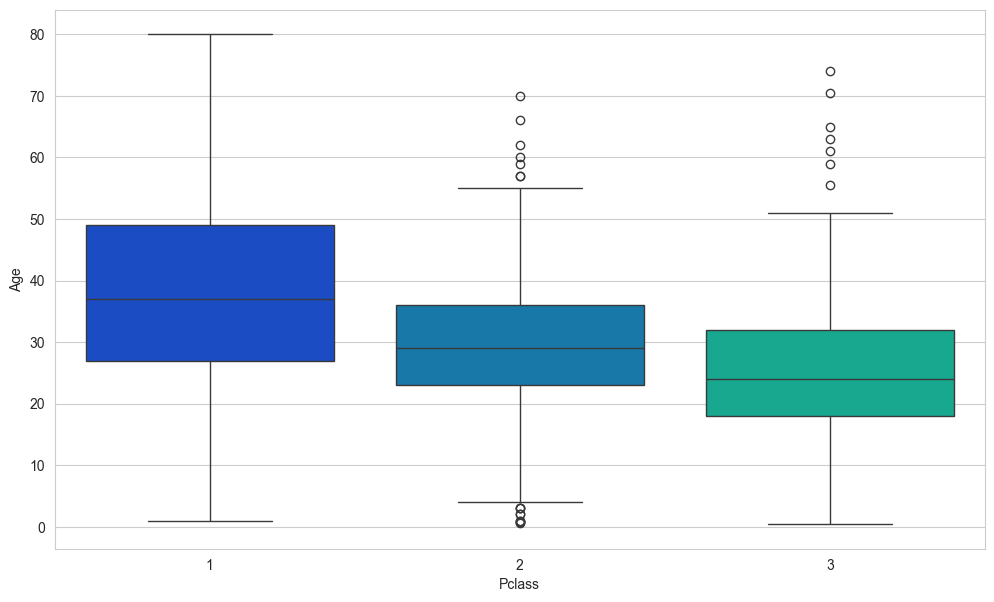

In [21]:
plt.figure(figsize=(12,7))
sns.boxplot(x="Pclass",y="Age",palette="winter",data=train)

In [ ]:
#  for pclass 1 avg age=37, pclass=2 -> 29 age plcalss=3 -> 24


In [23]:
def imputeage(cols):
    Age=cols[0]
    Pclass=cols[1]

    if pd.isnull(Age):

        if Pclass==1:
            return 37
        elif Pclass==2:
            return 29
        else:
            return 24
        
    else:
        return Age

In [24]:
# putting value
train['Age']=train[['Age','Pclass']].apply(imputeage,axis=1)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13136\3641474738.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age=cols[0]
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13136\3641474738.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass=cols[1]


<Axes: >

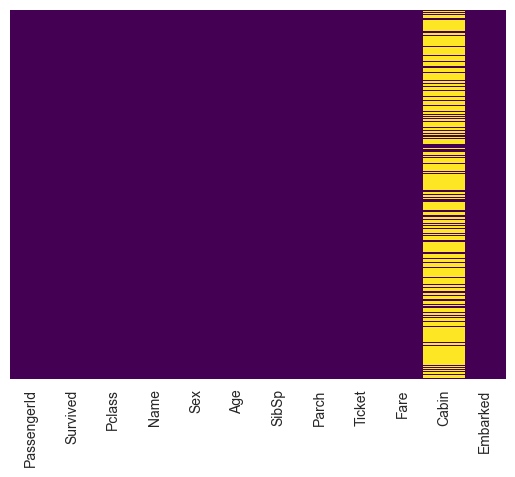

In [27]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')